### Image and Video Processing - Lab 1: Representation

In this lab, you will learn the basics image representation in Python. In addition, you will also apply the knowledge you learned in the Week 1 lecture to design a simplified version of PNG conversion.

**In order to complete the Lab, you need to finish all required tasks in the lab session and have one of the coordinators or TAs to check your result.**

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

#### Step 1: Read and display a grayscale image

We will load a grayscale image `DDW2024.jpg` using `cv2.imread()` with `cv2.IMREAD_GRAYSCALE` and display (using matplotlib).

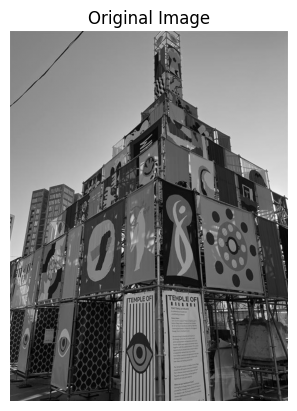

In [8]:
# Load a grayscale image
image = cv2.imread('DDW2024.jpg', cv2.IMREAD_GRAYSCALE)

# Display the original image
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

#### Step 2: Predictive Filtering

Calculate the filtered images using predictive filtering for X-A, X-B, X-Average from the lecture notes

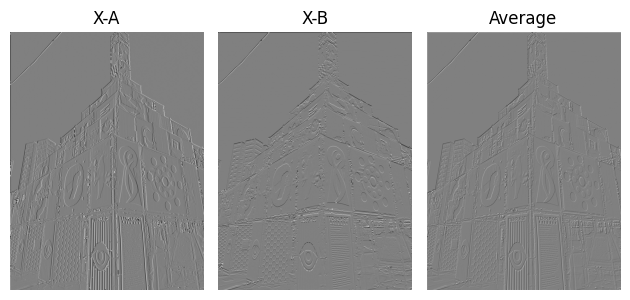

In [9]:

def predictive_filtering_X_A(img):
    delta_img = np.zeros_like(img)
    delta_img[:, 0] = img[:, 0]
    delta_img[:, 1:] = img[:, 1:] - img[:, :-1]
    return delta_img

def predictive_filtering_X_B(img):
    delta_img = np.zeros_like(img)
    delta_img[0, :] = img[0, :]
    delta_img[1:, :] = img[1:, :] - img[:-1, :]
    return delta_img

def predictive_filtering_Average(img):
    delta_img = np.zeros_like(img)
    delta_img[0, 0] = img[0, 0] // 2
    delta_img[0, 1:] = img[0, 1:] - img[0, :-1] // 2
    delta_img[1:, 0] = img[1:, 0] - img[:-1, 0] // 2
    delta_img[1:, 1:] = img[1:, 1:] - (img[1:, :-1] + img[:-1, 1:]) // 2
    return delta_img

img =  image.astype(np.int16)
#img = image

delta_left    = predictive_filtering_X_A(img).astype(np.int8)
delta_top     = predictive_filtering_X_B(img).astype(np.int8)
delta_average = predictive_filtering_Average(img).astype(np.int8)

# Display left delta
plt.subplot(1, 3, 1)
plt.imshow(delta_left, cmap='gray')
plt.title("X-A")
plt.axis("off")

# Display top delta
plt.subplot(1, 3, 2)
plt.imshow(delta_top, cmap='gray')
plt.title("X-B")
plt.axis("off")

# Display average delta
plt.subplot(1, 3, 3)
plt.imshow(delta_average, cmap='gray')
plt.title("Average")
plt.axis("off")

plt.tight_layout()
plt.show()

#### Step 3: Histogram Visualization

Visualize the histogram of all delta encoded images

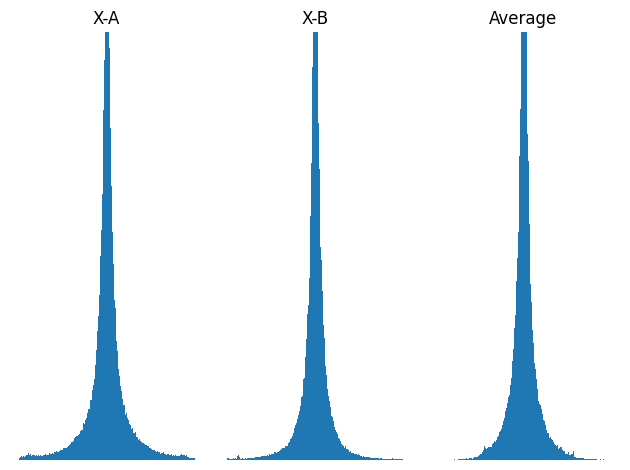

In [10]:
#Convert each delta to a 1D array

flat_delta_left    = delta_left.flatten()
flat_delta_top     = delta_top.flatten()
flat_delta_average = delta_average.flatten()

DIFF_VISIBLE = 1

# Histogram left delta
plt.subplot(1, 3, 1)
plt.hist(flat_delta_left, bins=256)
plt.title("X-A")
if DIFF_VISIBLE:
    # Sets the limit so the difference is visible
    plt.ylim(0, 10000) 
plt.axis("off")

# Histogram top delta
plt.subplot(1, 3, 2)
plt.hist(flat_delta_top, bins=256)
plt.title("X-B")
if DIFF_VISIBLE:
    # Sets the limit so the difference is visible
    plt.ylim(0, 10000) 
plt.axis("off")

# Histogram average delta
plt.subplot(1, 3, 3)
plt.hist(flat_delta_average, bins=256)
plt.title("Average")
if DIFF_VISIBLE:
    # Sets the limit so the difference is visible
    plt.ylim(0, 10000) 
plt.axis("off")

plt.tight_layout()
plt.show()

#### Step 4: Run-Length Encoding (RLE)

RLE is a simple form of lossless data compression. It is particularly effective for data that contains many consecutive repeated values.

The code should iterate through a sequence (like a list of numbers or a flattened image array) and counts how many times the same value appears in a row. Instead of storing every single value, it stores a pair: (value, count).

Finall calculate the compression ratio and the compressed sizes of each!

In [11]:
def rle_encode(data):
    encoded = []
    streak = 1
    for i in range(1, len(data)):
        if data[i] == data[i-1]:
            streak +=1
        else:
            encoded.append((data[i-1], streak))
            streak = 1
    encoded.append((data[-1], streak))
    return encoded

encode_left    = rle_encode(flat_delta_left)
encode_top     = rle_encode(flat_delta_top)
encode_average = rle_encode(flat_delta_average)

print("       Original length:", len(flat_delta_average))
print("   Left Encoded length:", len(encode_left), " Compression Ratio: ", (len(flat_delta_average)/len(encode_left)))
print("   Top  Encoded length:", len(encode_top), " Compression Ratio: ", (len(flat_delta_top)/len(encode_top)))
print("Average Encoded length:", len(encode_average), " Compression Ratio: ", (len(flat_delta_average)/len(encode_average)))


       Original length: 480000
   Left Encoded length: 343642  Compression Ratio:  1.3968024863084256
   Top  Encoded length: 287192  Compression Ratio:  1.6713557480709769
Average Encoded length: 331515  Compression Ratio:  1.4478982851454685
